In [19]:
# NAMA : ZIDANE SURYA NUGRAHA
# NIM : 607022400036
# KELAS : D3TK-48-01

#BAGIAN 1: Definisi Fungsi dan Persiapan Sinyal
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Definisi Fungsi Sinc Interpolation (Ideal)
def sinc_interp(x, s, u):
    if len(x) != len(s):
        raise ValueError('x and s must be the same length')

    T = np.diff(s).item(0)

    sincM = np.tile(u, (len(s), 1)) - np.tile(s[:, np.newaxis], (1, len(u)))
    y = np.dot(x, np.sinc(sincM / T))
    return y

# Persiapan Sinyal dan Proses Sampling
t_sample = np.linspace(0, 2*np.pi, 15)
t_recon = np.linspace(0, 2*np.pi, 500)

# Membuat 2 Jenis Sinyal
x1 = np.sin(t_sample)
x2 = np.sin(t_sample) + 0.5 * np.cos(3 * t_sample)

print("Bagian 1 berhasil di-run! Fungsi dan sinyal sudah siap.")

Bagian 1 berhasil di-run! Fungsi dan sinyal sudah siap.


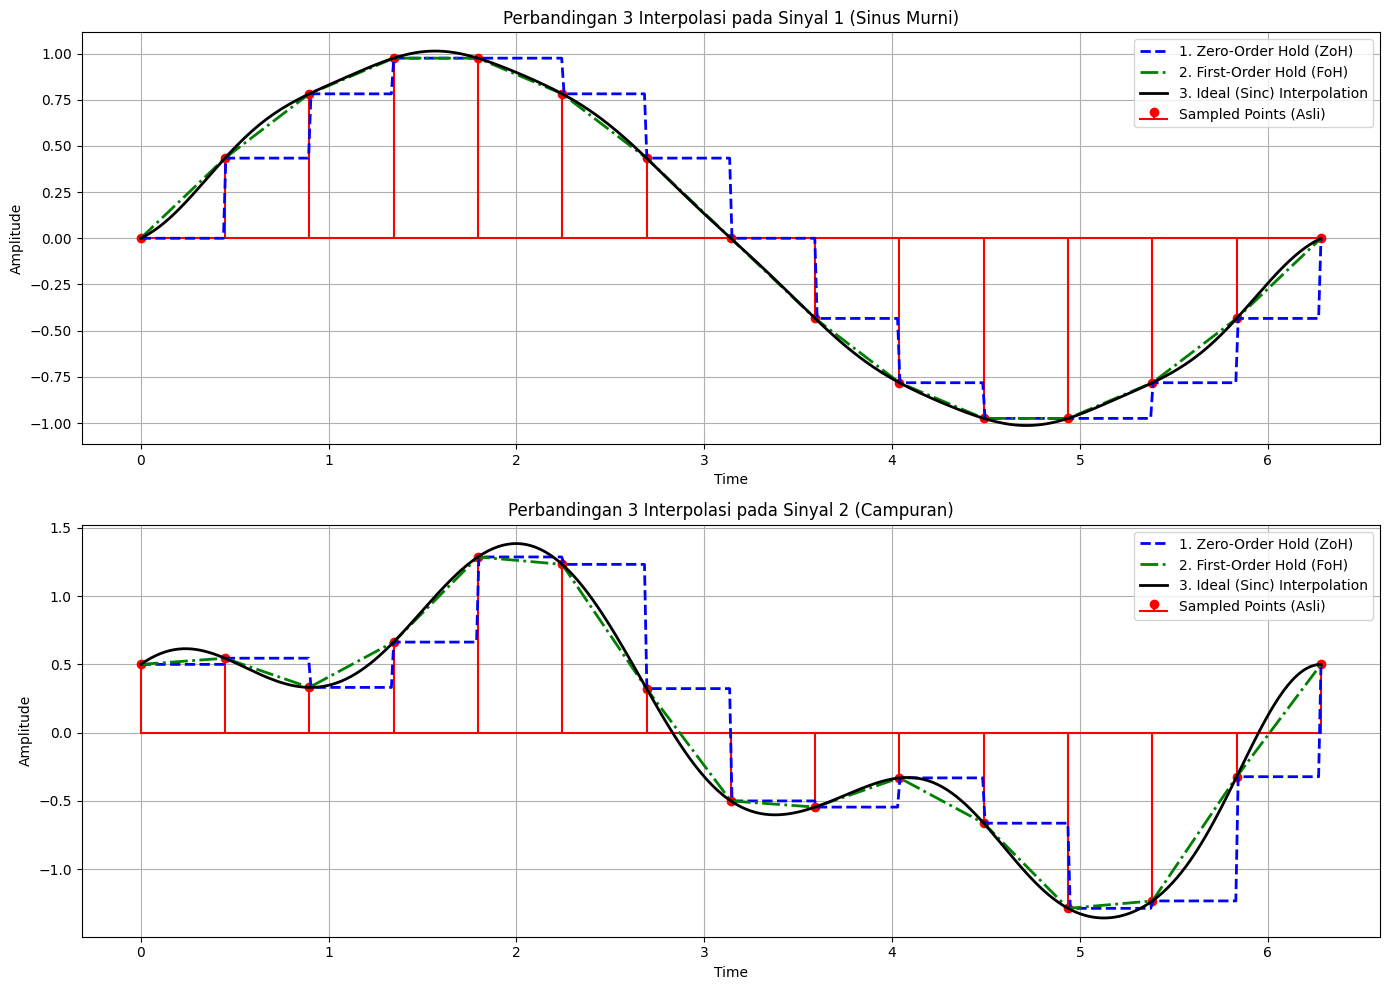

In [20]:
# BAGIAN 2: Proses Rekonstruksi Sinyal dan Plotting Grafik

# Rekonstruksi Sinyal 1 menggunakan 3 metode
zoh1 = interp1d(t_sample, x1, kind='previous')
foh1 = interp1d(t_sample, x1, kind='linear')
ideal1 = sinc_interp(x1, t_sample, t_recon)

# Rekonstruksi Sinyal 2 menggunakan 3 metode
zoh2 = interp1d(t_sample, x2, kind='previous')
foh2 = interp1d(t_sample, x2, kind='linear')
ideal2 = sinc_interp(x2, t_sample, t_recon)

# Plotting Hasil Perbandingan
plt.figure(figsize=(14, 10))

# Plot Perbandingan Sinyal 1
plt.subplot(2, 1, 1)
plt.stem(t_sample, x1, linefmt='r-', markerfmt='ro', basefmt='r-', label='Sampled Points (Asli)')
plt.plot(t_recon, zoh1(t_recon), 'b--', linewidth=2, label='1. Zero-Order Hold (ZoH)')
plt.plot(t_recon, foh1(t_recon), 'g-.', linewidth=2, label='2. First-Order Hold (FoH)')
plt.plot(t_recon, ideal1, 'k-', linewidth=2, label='3. Ideal (Sinc) Interpolation')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Perbandingan 3 Interpolasi pada Sinyal 1 (Sinus Murni)')
plt.legend(loc='best')
plt.grid(True)

# Plot Perbandingan Sinyal 2
plt.subplot(2, 1, 2)
plt.stem(t_sample, x2, linefmt='r-', markerfmt='ro', basefmt='r-', label='Sampled Points (Asli)')
plt.plot(t_recon, zoh2(t_recon), 'b--', linewidth=2, label='1. Zero-Order Hold (ZoH)')
plt.plot(t_recon, foh2(t_recon), 'g-.', linewidth=2, label='2. First-Order Hold (FoH)')
plt.plot(t_recon, ideal2, 'k-', linewidth=2, label='3. Ideal (Sinc) Interpolation')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Perbandingan 3 Interpolasi pada Sinyal 2 (Campuran)')
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()

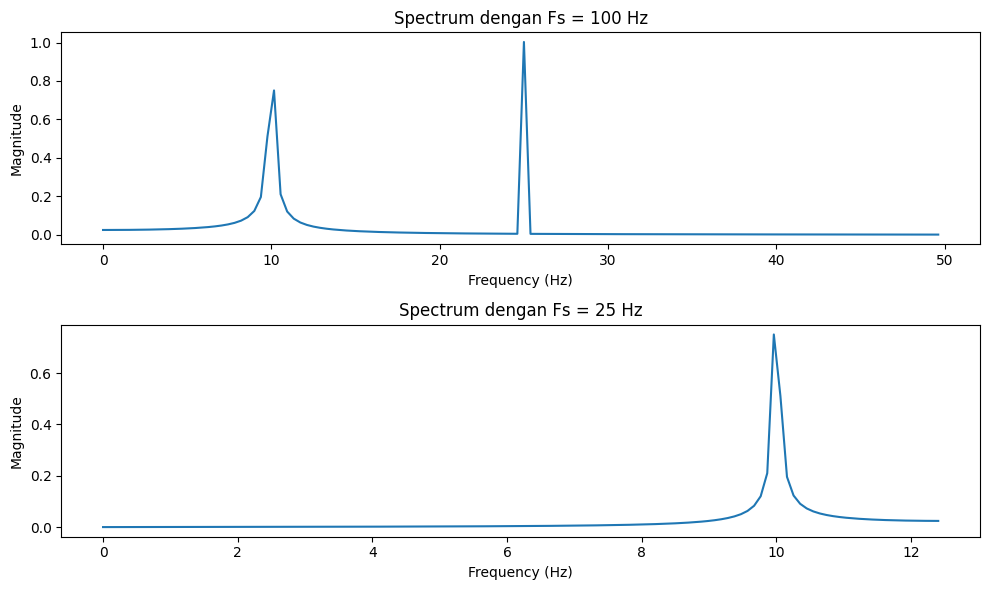

In [21]:
# EXERCISE 1: Aliasing in Frequency Domain
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Frekuensi didapat dari 20*pi*t (f1 = 10 Hz) dan 50*pi*t (f2 = 25 Hz)
f1, f2 = 10, 25
fs_list = (100, 25)

plt.figure(figsize=(10, 6))
for i, fs in enumerate(fs_list):
    T = 1/fs
    N = 256
    t = np.linspace(0, N*T, N, endpoint=False)
    x = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

    X = fft(x)
    f_axis = fftfreq(N, T)[:N//2]

    plt.subplot(2, 1, i+1)
    plt.plot(f_axis, 2/N * np.abs(X[:N//2]))
    plt.title(f'Spectrum dengan Fs = {fs} Hz')
    plt.xlabel('Frequency (Hz)'), plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()

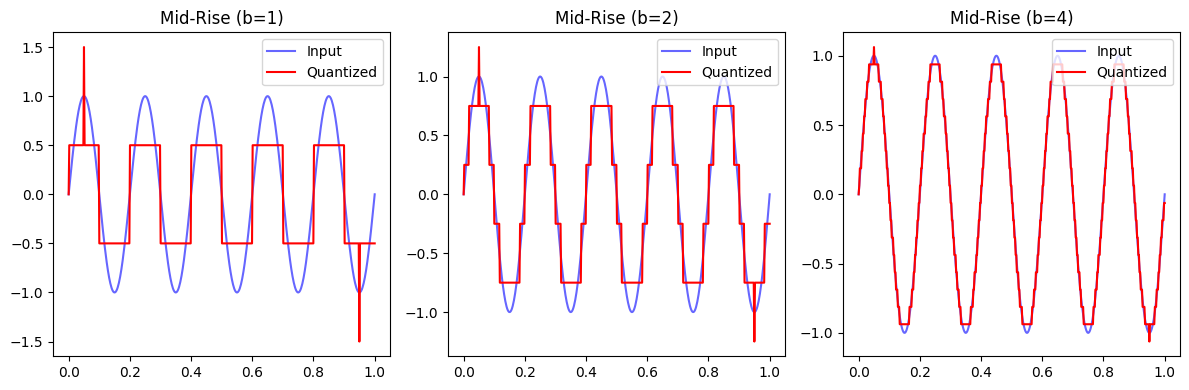

In [22]:
# EXERCISE 2: Uniform Mid-Rise Quantization
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 500)
x = np.sin(2 * np.pi * 5 * t)
DR = np.max(x) - np.min(x)
bits = (1, 2, 4)

plt.figure(figsize=(12, 4))
for i, b in enumerate(bits):
    L = 2**b
    q = DR / L
    # Mid-rise quantization
    y = np.sign(x) * q * (np.floor(np.abs(x)/q) + 0.5)

    plt.subplot(1, 3, i+1)
    plt.plot(t, x, label='Input', color='blue', alpha=0.6)
    plt.plot(t, y, label='Quantized', color='red')
    plt.title(f'Mid-Rise (b={b})')
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

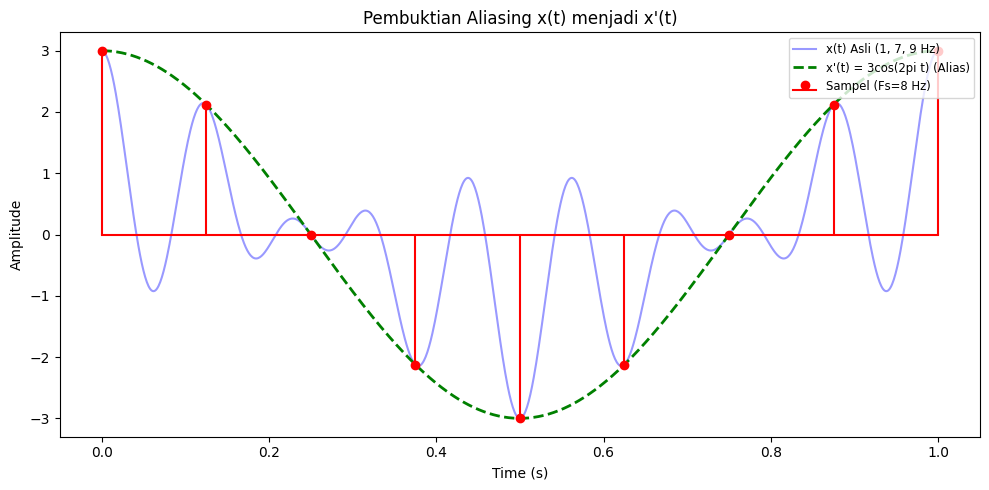

In [23]:
# EXERCISE 3: Aliasing Verification
import numpy as np
import matplotlib.pyplot as plt

# Sinyal kontinu
t_cont = np.linspace(0, 1, 1000)
x_cont = np.cos(2*np.pi*t_cont) + np.cos(14*np.pi*t_cont) + np.cos(18*np.pi*t_cont)
x_prime = 3 * np.cos(2*np.pi*t_cont)

# Sinyal diskrit (Sampling pada Fs = 8 Hz)
fs = 8
t_samp = np.arange(0, 1.1, 1/fs)
x_samp = np.cos(2*np.pi*t_samp) + np.cos(14*np.pi*t_samp) + np.cos(18*np.pi*t_samp)

plt.figure(figsize=(10, 5))
plt.plot(t_cont, x_cont, 'b-', alpha=0.4, label='x(t) Asli (1, 7, 9 Hz)')
plt.plot(t_cont, x_prime, 'g--', linewidth=2, label="x'(t) = 3cos(2pi t) (Alias)")
plt.stem(t_samp, x_samp, linefmt='r-', markerfmt='ro', basefmt='r-', label=f'Sampel (Fs={fs} Hz)')

plt.legend(loc='upper right', fontsize='small')
plt.xlabel('Time (s)'), plt.ylabel('Amplitude')
plt.title('Pembuktian Aliasing x(t) menjadi x\'(t)')
plt.tight_layout()
plt.show()

In [24]:
# EXERCISE 4: Audio Downsampling
import numpy as np
from IPython.display import Audio, display

fs = 8000
dur = 2 # Durasi 2 detik
t = np.linspace(0, dur, dur*fs, endpoint=False)
x = np.sin(2 * np.pi * 1300 * t)

print("1. Suara Asli (Frekuensi 1300 Hz, Fs = 8000 Hz):")
display(Audio(x, rate=fs))

# Proses Downsampling dengan faktor 2 (mengambil 1 sampel dari tiap 2 sampel)
x_down = x[::2]
fs_down = fs // 2 # Fs baru menjadi 4000 Hz

print("2. Suara Hasil Downsample (Dimainkan pada Fs = 4000 Hz):")
display(Audio(x_down, rate=fs_down))

1. Suara Asli (Frekuensi 1300 Hz, Fs = 8000 Hz):


2. Suara Hasil Downsample (Dimainkan pada Fs = 4000 Hz):


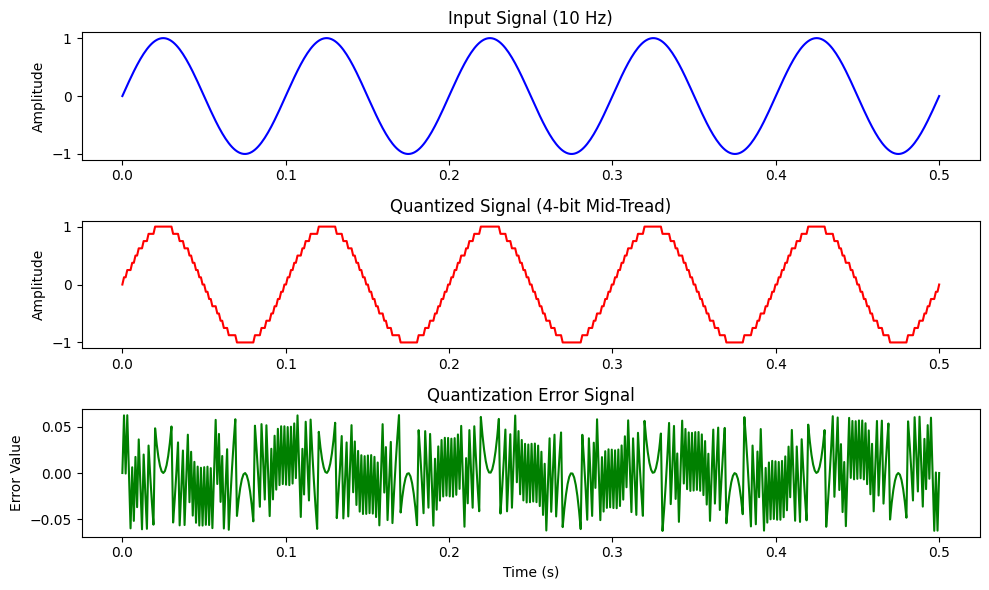

In [25]:
# EXERCISE 5: Mid-Tread Quantization & Error
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 0.5, 500) # Durasi 0.5s agar gelombang terlihat jelas
x = np.sin(2 * np.pi * 10 * t)
DR = np.max(x) - np.min(x)
b = 4
L = 2**b
q = DR / L

# Mid-tread quantization
y = np.sign(x) * q * np.floor((np.abs(x)/q) + 0.5)

# Sinyal error
e = y - x

plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(t, x, 'b')
plt.ylabel('Amplitude'), plt.title('Input Signal (10 Hz)')

plt.subplot(3, 1, 2)
plt.plot(t, y, 'r')
plt.ylabel('Amplitude'), plt.title('Quantized Signal (4-bit Mid-Tread)')

plt.subplot(3, 1, 3)
plt.plot(t, e, 'g')
plt.xlabel('Time (s)'), plt.ylabel('Error Value'), plt.title('Quantization Error Signal')

plt.tight_layout()
plt.show()